## АНАЛИЗ ЭФФЕКТИВНОСТИ ДВУХ ВАРИАНТОВ ПОСАДОЧНОЙ СТРАНИЦЫ

Представьте, что вы — Data Scientist в туристической фирме. Компания планирует запустить новую акцию, чтобы продать как можно больше туров. Команда разработала два варианта посадочной страницы официального сайта и провела A/B-тестирование. В результате эксперимента были собраны данные — скачайте их по ссылке ниже.

Вы должны убедиться, что A/B-тестирование было проведено корректно, проверить факт стабилизации метрик и обоснованно ответить на ключевой вопрос турагентства: какой вариант посадочной страницы более предпочтителен по метрикам конверсии и ежедневного среднего чека?

Итак, компания предлагает следующие варианты туров:

Таиланд — 100 000 рублей;

Турция — 60 000 рублей;

Мальдивы — 200 000 рублей;

Санкт-Петербург — 10 000 рублей;

Камчатка — 150 000 рублей.

Прочитаем наши данные и посмотрим на столбцы таблицы:

In [1]:
import pandas as pd
data = pd.read_csv(r'C:\Users\vladk\IDLE\Data\ab_data_tourist.csv')
data

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000
...,...,...,...,...,...
294473,751197,2021-01-03,A,0,0
294474,945152,2021-01-12,A,0,0
294475,734608,2021-01-22,A,0,0
294476,697314,2021-01-15,A,0,0


Наша таблица представлена следующими полями:

user_id — идентификатор пользователя, зашедшего на сайт;

data — дата посещения сайта;

group — группа теста (контрольная — А или тестовая — B);

purchase — признак покупки: совершил ли пользователь покупку тура (1 — да, 0 — нет);

price — цена купленного тура (если покупка не состоялась, цена равна 0).

### 1 Проанализируйте структуру данных и проведите их предобработку:

исследуйте структуру данных;

преобразуйте столбцы к необходимым типам данных.

Убедитесь в одинаковой длительности проведения A/B-тестирования в каждой из групп. Если длительность разная, унифицируйте данные, удалив лишние данные для соответствующей группы.

Проверьте данные на наличие пропусков и избавьтесь от них, если нужно.

Проверьте, есть ли пользователи, которые в процессе A/B-теста попали в обе группы. Если да, исключите пользователей, оказавшихся в обеих группах.

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


In [3]:
users_a = set(data[data['group'] == 'A']['user_id'])
users_b = set(data[data['group'] == 'B']['user_id'])

intersecting_users = users_a.intersection(users_b)

print(f"Количество пересекающихся пользователей: {len(intersecting_users)}")

Количество пересекающихся пользователей: 1895


In [4]:
print(f"Строк до очистки: {data.shape[0]}")
data = data[~data['user_id'].isin(intersecting_users)]
print(f"Строк после очистки: {data.shape[0]}")

Строк до очистки: 294478
Строк после очистки: 290688


Итак, в наших данных нет пропусков, однако нам нужно перевести столбец с информацией о дате события (timestamp) в формат datetime. 

In [5]:
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

C:\Users\vladk\AppData\Local\Temp\ipykernel_380\1498384830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')


В итоге мы получили таблицу, в которой отображены входы клиента на сайт (сессия) и его действия. Для того, чтобы получить показатель конверсии в группах на каждый день, нам необходимо предварительно сгруппировать наши данные по дате и группе и вычислить количество пользователей, заходивших на сайт, и суммарное количество совершённых целевых действий. 

In [6]:
daily_data = data.groupby(['date','group']).agg({
    'user_id':'count',
    'purchase':'sum'
}).reset_index().rename(columns={'user_id': 'users_count'})
daily_data.head()

,date,group,users_count,purchase
0,2021-01-02,A,2854,359
1,2021-01-02,B,2861,345
2,2021-01-03,A,6596,748
3,2021-01-03,B,6619,754
4,2021-01-04,A,6566,799


Для завершения этапа подготовки данных к анализу нам осталось рассчитать конверсию на каждый день проведения A/B-тестирования. Напомним: ежедневная конверсия рассчитывается как отношение числа посетителей сайта, выполнивших на нём какие-либо целевые действия в день, к ежедневному общему числу посетителей сайта, умноженная на 100 %:

In [7]:
daily_data['conversion'] = (daily_data['purchase']/daily_data['users_count'])*100

In [8]:
display(daily_data.head())

,date,group,users_count,purchase,conversion
0,2021-01-02,A,2854,359,12.578837
1,2021-01-02,B,2861,345,12.058721
2,2021-01-03,A,6596,748,11.340206
3,2021-01-03,B,6619,754,11.391449
4,2021-01-04,A,6566,799,12.168748


### ВИЗУАЛЬНЫЙ АНАЛИЗ КОНВЕРСИИ В ГРУППАХ

Нам необходимо ответить на вопрос: в какой группе (А или B) показатель конверсии был выше, и на этой основе принять решение о том, какой из вариантов более эффективный. 

Давайте построим диаграмму boxplot для сравнения параметров распределения ежедневной конверсии по группам. 

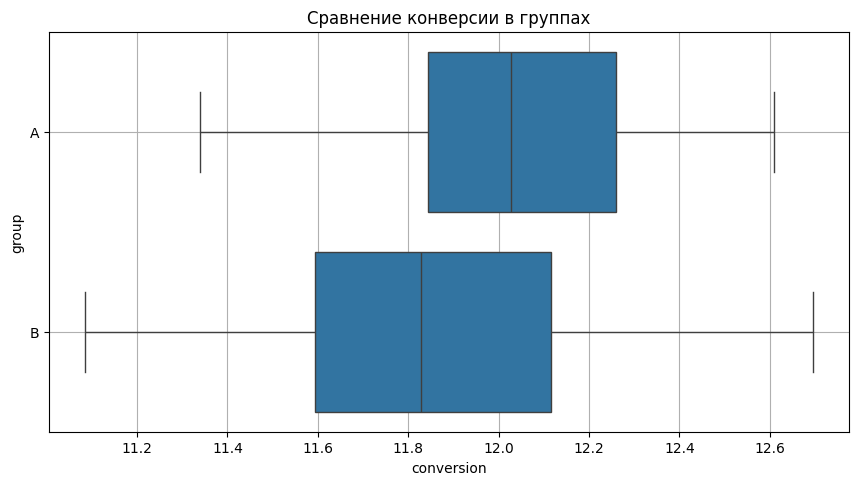

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# создаём фигуру размером 8x4
fig = plt.figure(figsize=(8, 4)) 
# добавляем систему координат
ax = fig.add_axes([1, 1, 1, 1]) 
# строим boxplot для conversion по признаку group
sns.boxplot(data=daily_data, x='conversion', y='group', ax=ax) 
# задаём подпись к графику
ax.set_title('Сравнение конверсии в группах')
# задаём отображение сетки
ax.grid(True)

Что можно сказать исходя из этого графика? Во-первых, медианное значение ежедневной конверсии в группе А, выше, чем в группе B. Во-вторых, разброс конверсии в группе B несколько больше, чем в группе A.

Примечание. Прежде чем делать выводы по визуальному представлению данных, всегда обращайте внимание на численные значения показателей. Они могут различаться в масштабе графика, но на практике разница между ними не будет иметь значения. Также всегда стоит убедиться, что в данных нет выбросов (базовый вариант — сравнить медиану и среднее между собой). Далее мы ещё поговорим о стабилизации показателя во времени.

Давайте вычислим средний и медианный показатель конверсии в контрольной и тестовой группе и умножим результат на 100 (получим результат в процентах):

In [10]:
conversion_piv = daily_data.groupby('group')['conversion'].agg(
    ['mean', 'median']
)
display(conversion_piv)

,mean,median
group,,
A,12.043320,12.028056
B,11.897725,11.828606


Из полученной таблицы видно, что медиана и среднее в каждой группе практически совпадают. При этом разница между показателями в группах менее 0.3 %! 

Возникает вопрос: а значима ли вообще такая разница в показателях или она обусловлена случайностью, и варианты A и B одинаково эффективны по метрике конверсии?

Прежде чем отвечать на этот вопрос, нам нужен ответ на другой вопрос: а стабилен ли показатель конверсии в группах во времени или он колеблется как «уж на сковородке»?

Посмотрим, как вообще изменялись показатели ежедневной конверсии в каждой группе во времени. Для этого построим линейные графики для каждой группы: по оси абсцисс отложим дату, а по оси ординат — показатель конверсии:

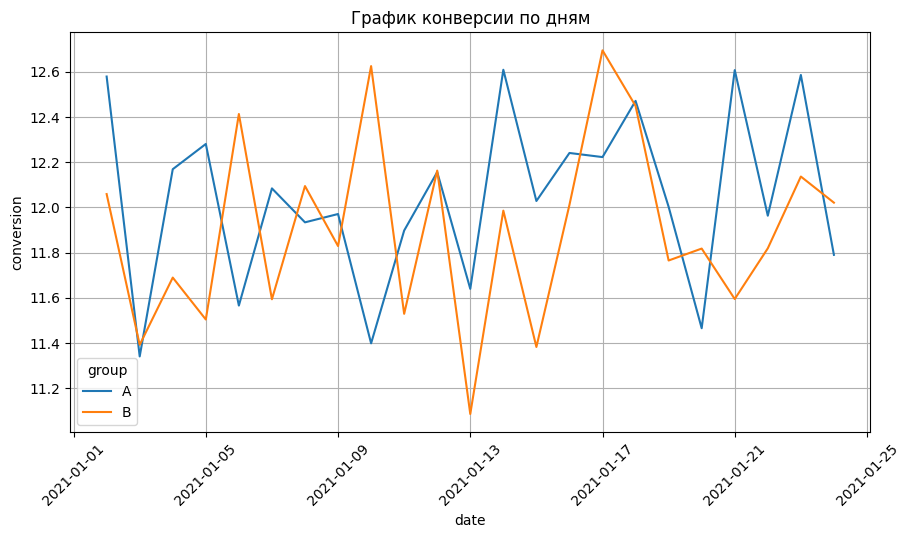

In [11]:
# создаём фигуру размером 8x4
fig = plt.figure(figsize=(8, 4))
# добавляем систему координат
ax = fig.add_axes([1, 1, 1, 1])
# строим lineplot для конверсии во времени в каждой группе
sns.lineplot(
    data=daily_data,
    x='date',
    y='conversion',
    hue='group', 
    ax=ax
)
# задаём подпись к графику
ax.set_title('График конверсии по дням')
# задаём поворот меток на оси абсцисс
ax.xaxis.set_tick_params(rotation=45)
# задаём отображение сетки
ax.grid(True)

Рассчитаем кумулятивную конверсию — это отношение ежедневной кумулятивной суммы количества посетителей к ежедневной кумулятивной сумме количества совершённых целевых действий:

In [12]:
# вычисляем кумулятивную сумму количества посетителей
daily_data['cum_users_count'] = daily_data.groupby(['group'])['users_count'].cumsum()
# вычисляем кумулятивную сумму количества совершённых целевых действий
daily_data['cum_converted'] = daily_data.groupby(['group'])['purchase'].cumsum()
# вычисляем кумулятивную конверсию
daily_data['cum_conversion'] = daily_data['cum_converted']/daily_data['cum_users_count'] * 100
display(daily_data.head())

,date,group,users_count,purchase,conversion,cum_users_count,cum_converted,cum_conversion
0,2021-01-02,A,2854,359,12.578837,2854,359,12.578837
1,2021-01-02,B,2861,345,12.058721,2861,345,12.058721
2,2021-01-03,A,6596,748,11.340206,9450,1107,11.714286
3,2021-01-03,B,6619,754,11.391449,9480,1099,11.592827
4,2021-01-04,A,6566,799,12.168748,16016,1906,11.900599


А теперь построим графики кумулятивной конверсии по дням в каждой группе:

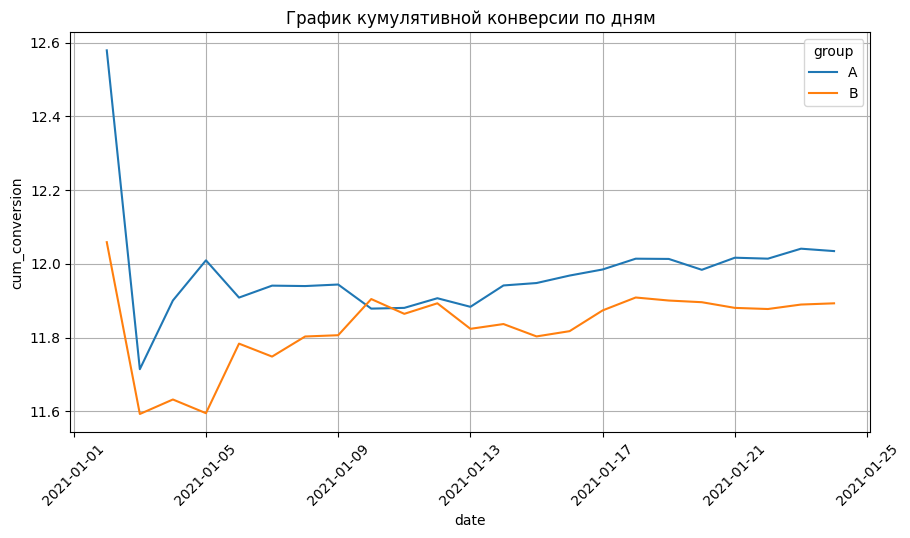

In [13]:
# создаём фигуру размером 8x4
fig = plt.figure(figsize=(8, 4))
# добавляем систему координат
ax = fig.add_axes([1, 1, 1, 1])
# строим lineplot для кумулятивной конверсии во времени в каждой группе
sns.lineplot(x='date', y='cum_conversion', data=daily_data, hue='group', ax=ax)
# задаём подпись к графику
ax.set_title('График кумулятивной конверсии по дням')
# задаём поворот меток на оси абсцисс
ax.xaxis.set_tick_params(rotation = 45)
# задаём отображение сетки
ax.grid(True)

### 2 Сделайте первичный анализ результатов A/B-тестирования:

Рассчитайте вспомогательные показатели для контрольной и тестовой групп:

количество посещений сайта;

суммарное количество совершённых покупок;

сумма всех покупок.

Сделайте промежуточные выводы по построенной таблице. Сопоставимо ли количество посещений обоих вариантов посадочной страницы? Можно ли говорить о сбалансированности выборок?

В каждой из групп рассчитайте ключевые показатели:

конверсия;

средний чек.

Сделайте первичные выводы о результатах A/B-тестирования на основе показателей конверсии и среднего чека в каждой из групп. По какому(-им) показателю(-ям), на первый взгляд, вариант А эффективнее варианта B и наоборот?

Сравните варианты A/B по покупательской способности каждого из туров. Для этого постройте сводную таблицу, которая покажет зависимость количества продаж от группы и цены тура. Визуализируйте полученную сводную таблицу.

Сделайте выводы по построенной таблице. По каким турам покупательская способность участников группы А выше, чем покупательская способность участников группы B, и наоборот?

In [14]:
auxiliary_metrics = data.groupby('group').agg({
    'user_id': 'count',       # количество посещений сайта
    'purchase': 'sum',        # суммарное количество совершённых покупок
    'price': 'sum'            # сумма всех покупок
}).rename(columns={
    'user_id': 'visits_count',
    'purchase': 'purchases_count',
    'price': 'revenue'
})

# Выводим табличку на экран
display(auxiliary_metrics)

,visits_count,purchases_count,revenue
group,,,
A,145307,17487,1417780000
B,145381,17290,1533010000


Количество посещений сопоставимо: В группе А зафиксировано 145 307 визитов, а в B — 145 381 визит. Выборки сбалансированы. Разница в количестве посетителей между группами составляет менее 0.1%.

In [15]:
purchases_only = data[data['purchase'] == 1]

pivot_tours = pd.pivot_table(
    purchases_only,
    values='user_id', 
    index='price',  
    columns='group', 
    aggfunc='count',  
    fill_value=0     
)

display(pivot_tours)

group,A,B
price,,
10000,5182,5201
60000,5271,1730
100000,1832,5227
150000,3478,3438
200000,1724,1694


На первый взгляд, вариант посадочной страницы А 12.03% оказался немного эффективнее варианта B 11.89% в конвертации посетителей в покупателей

Несмотря на легкое проседание в конверсии, вариант посадочной страницы B показал себя значительно эффективнее по бизнес-метрикам. Ежедневный средний чек в группе B составил 88 664 руб против 81 076 руб в группе А, что в итоге принесло компании заметно большую суммарную выручку

Text(970.7222222222223, 0.5, 'Цена тура (руб.)')

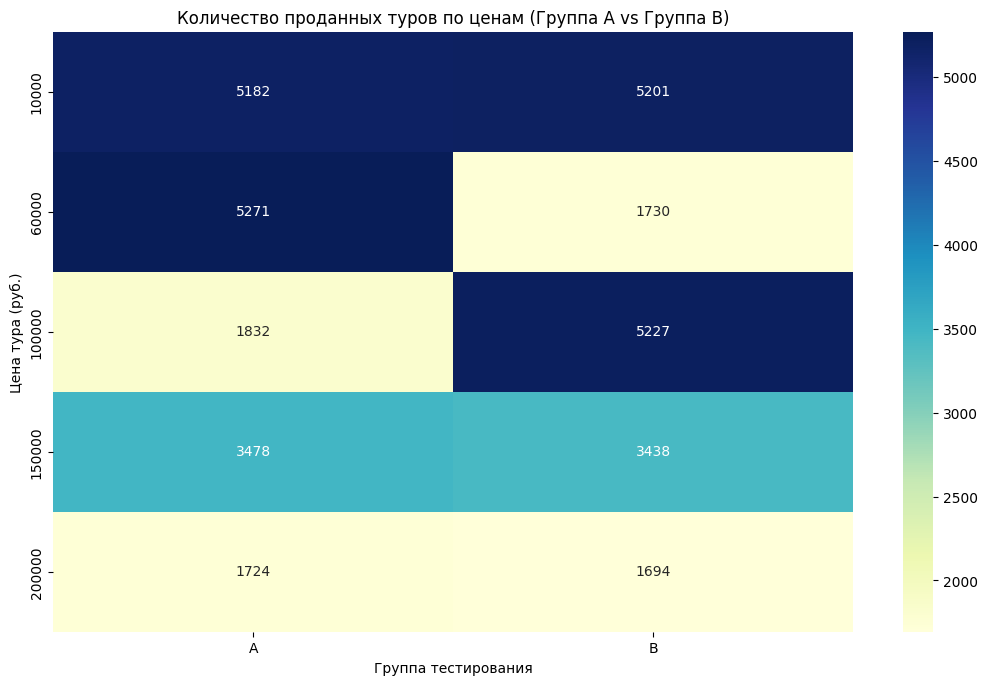

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
ax = fig.add_axes([1, 1, 1, 1])

# Строим тепловую карту
sns.heatmap(pivot_tours, annot=True, fmt='d', cmap='YlGnBu', ax=ax)

ax.set_title('Количество проданных туров по ценам (Группа А vs Группа B)')
ax.set_xlabel('Группа тестирования')
ax.set_ylabel('Цена тура (руб.)')

Покупательская способность пользователей по турам за 10 000 руб, 150 000 руб и 200 000 руб практически идентична в обеих группах.

Вариант А значительно эффективнее продает туры средней ценовой категории. Покупательская способность по турам за 60 000 руб в группе А в 3 раза выше, чем в группе B (5 271 покупка против 1 730).

Вариант B успешно смещает фокус внимания клиентов на более дорогие путевки. Покупательская способность по турам за 100 000 руб в группе B почти в 3 раза выше, чем в контрольной группе (5 227 покупок против 1 832).

### 3 Проанализируйте данные на предмет стабилизации метрик:

Сгруппируйте данные по дате и группе тестирования и постройте таблицу с ежедневными данными результатов проведения A/B-тестирования. В каждой группе вычислите ежедневные показатели:

количество посещений страницы;

количество покупок;

сумму покупок.

Добавьте в таблицу информацию о ежедневной конверсии (ежедневное количество покупок / ежедневное количество посещений) в группе и о ежедневном среднем чеке (ежедневная сумма покупок / ежедневное количество покупок).

Рассчитайте кумулятивные показатели:

кумулятивное количество посещений страницы;

кумулятивное количество покупок;

кумулятивную сумму покупок.

На основе полученных кумулятивных показателей вычислите кумулятивную конверсию и кумулятивный средний чек.

Постройте кумулятивные графики конверсии и среднего чека в каждой группе по дням.

Сделайте выводы. Можно ли назвать A/B-тест завершённым? Стабилизировались ли значения метрик во времени? Как соотносятся кумулятивные показатели в каждой группе?

In [ ]:
# Группируем данные по дате и группе
daily_data = data.groupby(['date', 'group']).agg({
    'user_id': 'count',    # количество посещений
    'purchase': 'sum',     # количество покупок
    'price': 'sum'         # сумма покупок (выручка)
}).reset_index()

# Переименовываем столбцы для удобства
daily_data = daily_data.rename(columns={
    'user_id': 'users_count',
    'purchase': 'purchases_count',
    'price': 'revenue'
})

# Добавляем ежедневную конверсию в %
daily_data['conversion'] = (daily_data['purchases_count'] / daily_data['users_count']) * 100
# Добавляем ежедневный средний чек
daily_data['average_check'] = daily_data['revenue'] / daily_data['purchases_count']

display(daily_data.head())

,date,group,users_count,purchases_count,revenue,conversion,average_check
0,2021-01-02,A,2854,359,29410000,12.578837,81922.005571
1,2021-01-02,B,2861,345,29660000,12.058721,85971.014493
2,2021-01-03,A,6596,748,62000000,11.340206,82887.700535
3,2021-01-03,B,6619,754,65960000,11.391449,87480.106101
4,2021-01-04,A,6566,799,64250000,12.168748,80413.016270


In [ ]:
# сортируем по дате 
daily_data = daily_data.sort_values(by='date')

# Вычисляем кумулятивные показатели внутри каждой группы
daily_data['cum_users_count'] = daily_data.groupby('group')['users_count'].cumsum()
daily_data['cum_purchases'] = daily_data.groupby('group')['purchases_count'].cumsum()
daily_data['cum_revenue'] = daily_data.groupby('group')['revenue'].cumsum()

# На основе кумулятивных сумм рассчитываем кумулятивную конверсию и кумулятивный средний чек
daily_data['cum_conversion'] = (daily_data['cum_purchases'] / daily_data['cum_users_count']) * 100
daily_data['cum_average_check'] = daily_data['cum_revenue'] / daily_data['cum_purchases']

display(daily_data[['date', 'group', 'cum_conversion', 'cum_average_check']].head())

,date,group,cum_conversion,cum_average_check
0,2021-01-02,A,12.578837,81922.005571
1,2021-01-02,B,12.058721,85971.014493
2,2021-01-03,A,11.714286,82574.525745
3,2021-01-03,B,11.592827,87006.369427
4,2021-01-04,A,11.900599,81668.415530


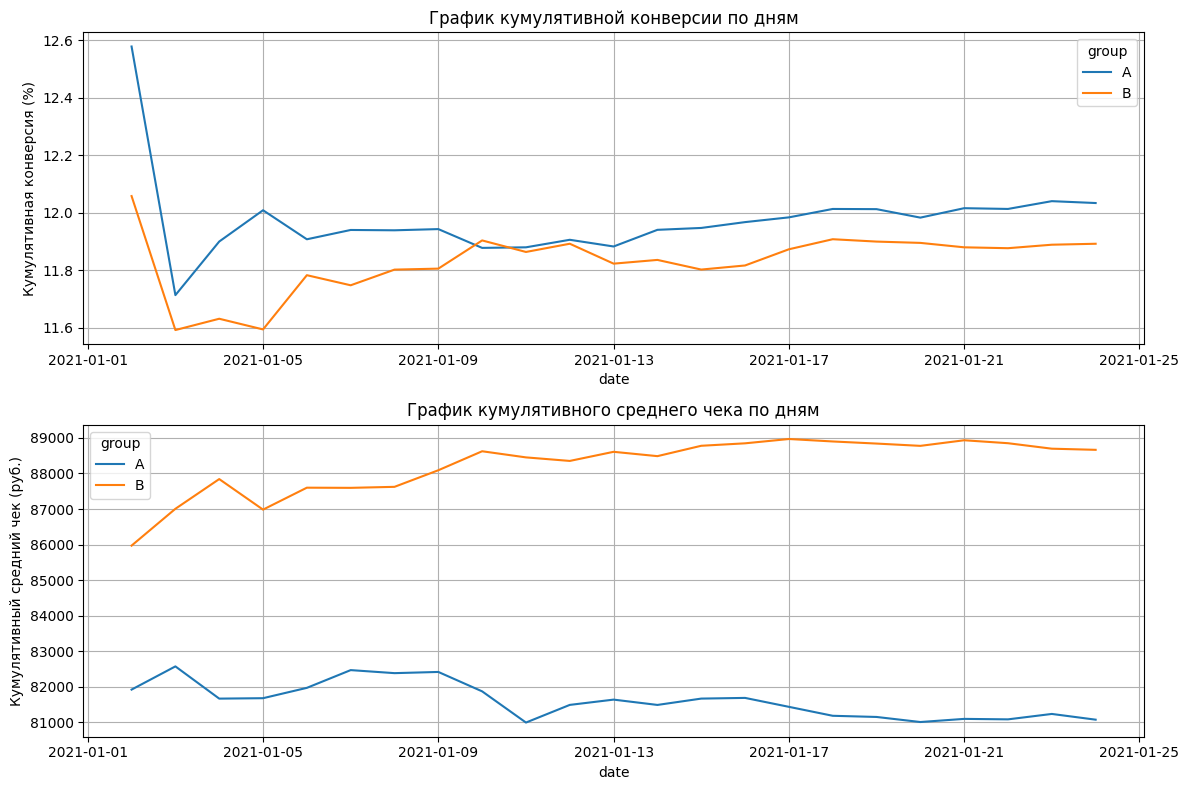

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем фигуру с двумя графиками (один под другим)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- График 1: Кумулятивная конверсия ---
sns.lineplot(data=daily_data, x='date', y='cum_conversion', hue='group', ax=axes[0])
axes[0].set_title('График кумулятивной конверсии по дням')
axes[0].set_ylabel('Кумулятивная конверсия (%)')
axes[0].grid(True)

# --- График 2: Кумулятивный средний чек ---
sns.lineplot(data=daily_data, x='date', y='cum_average_check', hue='group', ax=axes[1])
axes[1].set_title('График кумулятивного среднего чека по дням')
axes[1].set_ylabel('Кумулятивный средний чек (руб.)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Метрики стабилизировались с течением времени, значит, случайные выбросы первых дней больше не искажают картину. Данных собрано достаточно, и A/B-тест можно назвать завершённым. На графике кумулятивной конверсии А немного выше чем В, а на графике кумулятивного среднего чека В сильно выше А, то есть вариант А привлекает больше покупателей, но они покупают более дешёвые туры, а вариант Б привлекает меньше людей, но зато те, кто покупает, выбирают дорогие туры.

### 4 Проведите статистический анализ результатов A/B-тестирования:

Сформулируйте статистические гипотезы, соответствующие поставленным бизнес-вопросам, и выберите статистический тест для их проверки.

Не забудьте проверить данные на нормальность там, где это необходимо.

С помощью аппарата статистических тестов определите:

Есть ли статистическая разница между конверсиями в группах А и B?

Есть ли статистическая разница между ежедневными средними чеками в группах А и B?

Подкрепите результаты статистических тестов, построив 95 % доверительные интервалы для:

конверсий в каждой из групп;

разницы конверсий в группах;

ежедневного среднего чека в каждой из групп.

Проинтерпретируйте построенные доверительные интервалы для конверсий и ежедневного среднего чека в группах. Есть ли перекрытие между доверительными интервалами для групп? Если есть, то о чём это говорит?

1. Гипотезы для метрики: Конверсия

Бизнес-вопрос: Есть ли статистическая разница между конверсиями в группах А и B?

Нулевая гипотеза ($H_0$): Конверсии в группах А и B равны (статистически значимой разницы нет).

Альтернативная гипотеза ($H_1$): Конверсии в группах А и B не равны (статистическая разница есть).

Выбранный тест: Z-тест для пропорций. Конверсия — это доля (пропорция) целевых действий от общего числа сессий. Для сравнения двух долей в независимых выборках оптимально подходит именно Z-тест.

2. Гипотезы для метрики: Ежедневный средний чек

Бизнес-вопрос: Есть ли статистическая разница между ежедневными средними чеками в группах А и B?

Нулевая гипотеза ($H_0$): Ежедневные средние чеки в группах А и B равны (статистически значимой разницы нет).

Альтернативная гипотеза ($H_1$): Ежедневные средние чеки в группах А и B не равны (статистическая разница есть).

Выбранный алгоритм тестирования: 1. Так как средний чек — это количественная метрика, сначала данные необходимо проверить на нормальность распределения с помощью критерия Шапиро-Уилка. 2. Если распределение окажется нормальным, для проверки гипотезы будет использован T-тест (t-критерий Стьюдента). 3. Если распределение отлично от нормального, будет применен непараметрический U-критерий Манна-Уитни.

### Статистическая разница между конверсиями

In [23]:
from statsmodels.stats.proportion import proportions_ztest

# Сгруппируем данные по группам для получения общего числа посетителей и покупок
conversion_piv = data.groupby('group')['purchase'].agg(['sum', 'count'])

# Передаем количество покупок (успехов) и общее число посетителей (наблюдений)
z_stat, p_val_conv = proportions_ztest(
    count=conversion_piv['sum'], 
    nobs=conversion_piv['count'], 
    alternative='two-sided'
)

print(f"Z-тест для конверсии. p-value: {p_val_conv:.4f}")
if p_val_conv <= 0.05:
    print("Разница в конверсиях статистически значима! Отвергаем нулевую гипотезу.")
else:
    print("Нет статистически значимой разницы в конверсиях. Нулевую гипотезу отвергнуть нельзя.")

Z-тест для конверсии. p-value: 0.2394
Нет статистически значимой разницы в конверсиях. Нулевую гипотезу отвергнуть нельзя.


### Статистическая разница между средними чеками

In [24]:
from scipy.stats import shapiro, mannwhitneyu, ttest_ind

# Выделяем ряды ежедневных средних чеков для групп А и B
daily_a = daily_data[daily_data['group'] == 'A']['average_check']
daily_b = daily_data[daily_data['group'] == 'B']['average_check']

# Проверка на нормальность распределения (Тест Шапиро-Уилка)
_, p_shapiro_a = shapiro(daily_a)
_, p_shapiro_b = shapiro(daily_b)

print(f"Шапиро-Уилк (Группа А) p-value: {p_shapiro_a:.4f}")
print(f"Шапиро-Уилк (Группа B) p-value: {p_shapiro_b:.4f}")

# Выбираем статистический тест на основе нормальности
if p_shapiro_a > 0.05 and p_shapiro_b > 0.05:
    # Если оба распределения нормальные — используем Т-тест
    t_stat, p_val_check = ttest_ind(daily_a, daily_b, equal_var=False)
    print(f"Применяем Т-тест (Уэлча). p-value: {p_val_check:.4f}")
else:
    # Если хотя бы одно распределение не нормальное — используем тест Манна-Уитни
    u_stat, p_val_check = mannwhitneyu(daily_a, daily_b, alternative='two-sided')
    print(f"Применяем тест Манна-Уитни. p-value: {p_val_check:.4f}")

if p_val_check <= 0.05:
    print("Разница в ежедневных средних чеках статистически значима! Отвергаем нулевую гипотезу.")
else:
    print("Нет статистически значимой разницы в средних чеках. Нулевую гипотезу отвергнуть нельзя.")

Шапиро-Уилк (Группа А) p-value: 0.2531
Шапиро-Уилк (Группа B) p-value: 0.0938
Применяем Т-тест (Уэлча). p-value: 0.0000
Разница в ежедневных средних чеках статистически значима! Отвергаем нулевую гипотезу.


### Доверительные интервалы для конверсий и средних чеков

In [26]:
import numpy as np
from scipy.stats import norm, t

# --- Функции для расчета интервалов ---
def proportions_conf_interval(n, x_p, gamma=0.95):   
    alpha = 1 - gamma
    z_crit = -norm.ppf(alpha/2)
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5
    return x_p - eps, x_p + eps

def diff_proportions_conf_interval(n, x_p, gamma=0.95):
    alpha = 1 - gamma
    z_crit = -norm.ppf(alpha/2)
    diff = x_p[1] - x_p[0]
    eps = z_crit * (x_p[0] * (1 - x_p[0]) / n[0] + x_p[1] * (1 - x_p[1]) / n[1]) ** 0.5
    return diff - eps, diff + eps

def mean_conf_interval(data_sample, gamma=0.95):
    n = len(data_sample)
    x_mean = data_sample.mean()
    x_std = data_sample.std()
    alpha = 1 - gamma
    t_crit = -t.ppf(alpha/2, df=n-1)
    eps = t_crit * (x_std / (n ** 0.5))
    return x_mean - eps, x_mean + eps

# --- Расчет для Конверсий ---
n_a = conversion_piv.loc['A', 'count']
n_b = conversion_piv.loc['B', 'count']
xp_a = conversion_piv.loc['A', 'sum'] / n_a
xp_b = conversion_piv.loc['B', 'sum'] / n_b

ci_a_conv = proportions_conf_interval(n_a, xp_a)
ci_b_conv = proportions_conf_interval(n_b, xp_b)
ci_diff_conv = diff_proportions_conf_interval([n_a, n_b], [xp_a, xp_b])

print("Доверительные интервалы для конверсии")
print(f"Группа А: [{ci_a_conv[0]*100:.2f}%, {ci_a_conv[1]*100:.2f}%]")
print(f"Группа B: [{ci_b_conv[0]*100:.2f}%, {ci_b_conv[1]*100:.2f}%]")
print(f"Разница конверсий (B - A): [{ci_diff_conv[0]*100:.2f}%, {ci_diff_conv[1]*100:.2f}%]\n")

# --- Расчет для Среднего Чека ---
ci_a_check = mean_conf_interval(daily_a)
ci_b_check = mean_conf_interval(daily_b)

print("Доверительные интервалы для ежедневного среднего чека")
print(f"Группа А: [{ci_a_check[0]:.2f} руб., {ci_a_check[1]:.2f} руб.]")
print(f"Группа B: [{ci_b_check[0]:.2f} руб., {ci_b_check[1]:.2f} руб.]")

Доверительные интервалы для конверсии
Группа А: [11.87%, 12.20%]
Группа B: [11.73%, 12.06%]
Разница конверсий (B - A): [-0.38%, 0.09%]

Доверительные интервалы для ежедневного среднего чека
Группа А: [79630.35 руб., 82308.22 руб.]
Группа B: [87625.83 руб., 89525.61 руб.]


Доверительные интервалы для конверсии говорят о том, что между конверсиями в группах А и B нет статистически значимой разницы. Несмотря на то, что на кумулятивном графике линия А была чуть выше, с точки зрения математики оба варианта дают одинаковую конверсию, а небольшие колебания вызваны случайностью.

Отсутствие перекрытия доверительных интервалов для ежедневного среднего чека с 95% вероятностью доказывает, что ежедневный средний чек в группе B статистически значимо выше, чем в группе А, что подтвержает выводы из графика.

### 5 Сделайте общий вывод по результатам A/B-теста.

Какой варианта дизайна посадочной страницы более эффективен по метрикам конверсии и ежедневного среднего чека и почему?

Основываясь на проведенном визуальном и статистическом анализе, вариант дизайна B является более эффективным и рекомендуется к полноценному внедрению.

Так как оба варианта страницы привлекают одинаковую долю покупателей, но при этом пользователи, взаимодействующие с вариантом B, покупают существенно более дорогие туры, вариант B принесет компании больше выручки. Компании следует завершить тестирование, отказаться от старого дизайна (вариант А) и перевести 100% трафика на новую посадочную страницу (вариант B).